# ブラック-ショールズ方程式の数理とPython実装
## オプション価格とグリークスを理論から導出する

このノートブックは、Zenn記事「ブラック-ショールズ方程式の数理とPython実装」の実装コードです。

## 0. 環境セットアップ

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

# 共通パラメータ
S0 = 100    # 原資産価格
K = 100     # 行使価格
r = 0.05    # リスクフリーレート
sigma = 0.2 # ボラティリティ

## 1. オプションのペイオフ

**コール**: $\text{Payoff} = \max(S_T - K, 0)$

**プット**: $\text{Payoff} = \max(K - S_T, 0)$

### 図1: コール・プットのペイオフ図

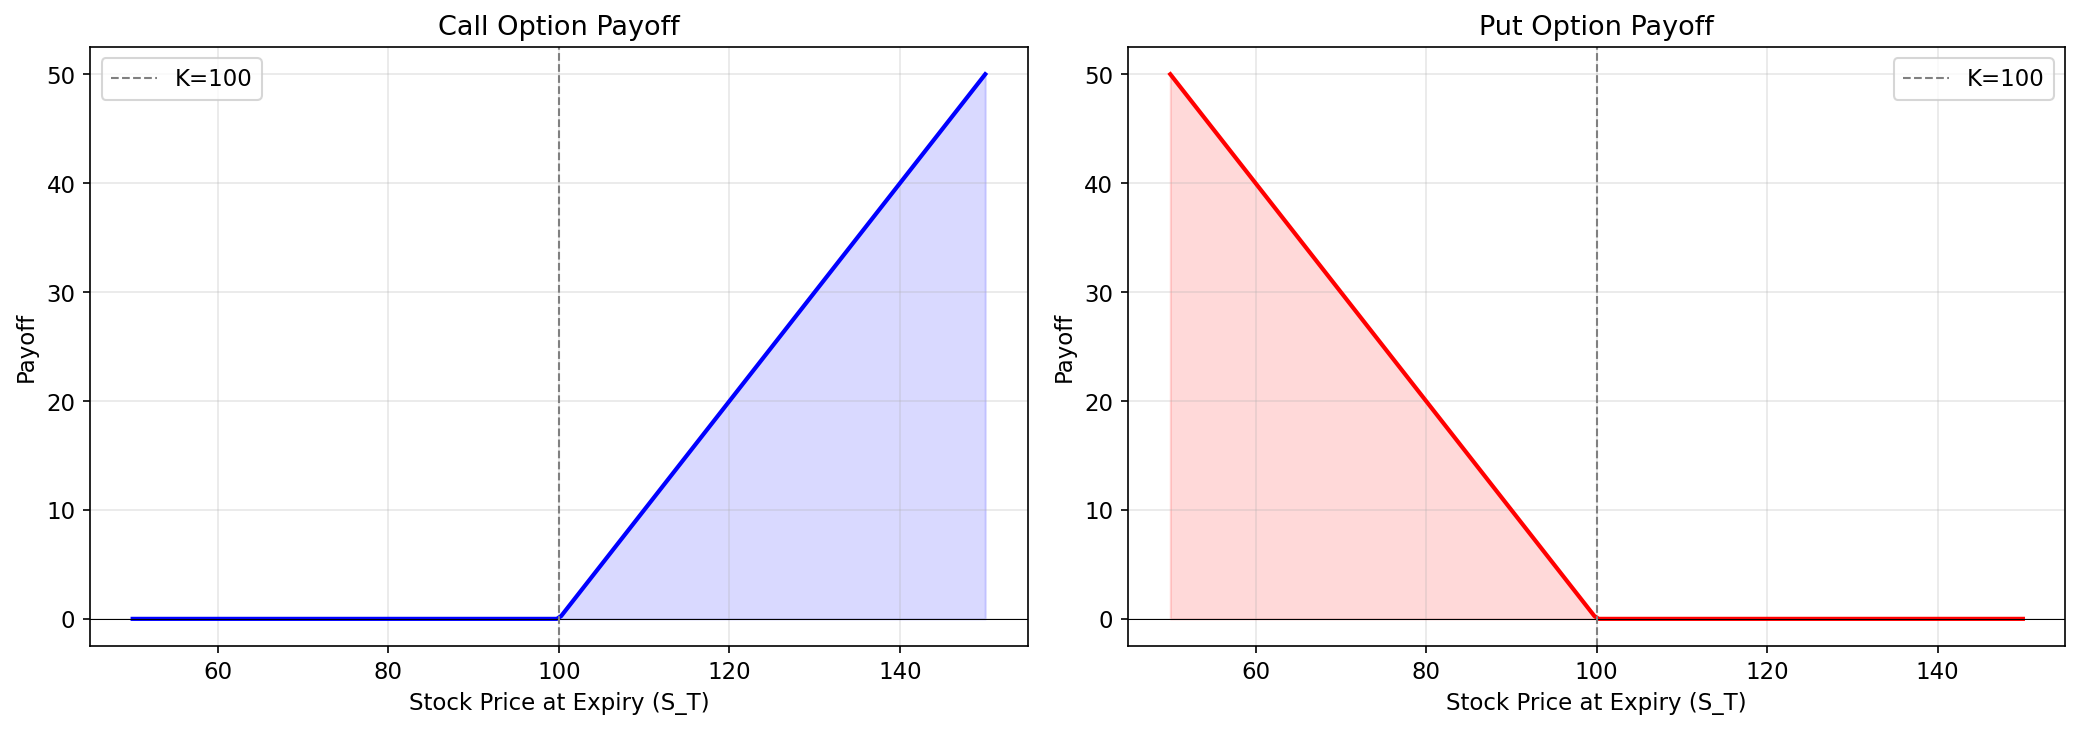

In [2]:
S_range = np.linspace(50, 150, 200)

call_payoff = np.maximum(S_range - K, 0)
put_payoff = np.maximum(K - S_range, 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(S_range, call_payoff, 'b-', linewidth=2)
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'K={K}')
axes[0].set_title('Call Option Payoff', fontsize=13)
axes[0].set_xlabel('Stock Price at Expiry (S_T)')
axes[0].set_ylabel('Payoff')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(S_range, call_payoff, alpha=0.15, color='blue')

axes[1].plot(S_range, put_payoff, 'r-', linewidth=2)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'K={K}')
axes[1].set_title('Put Option Payoff', fontsize=13)
axes[1].set_xlabel('Stock Price at Expiry (S_T)')
axes[1].set_ylabel('Payoff')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(S_range, put_payoff, alpha=0.15, color='red')

plt.tight_layout()
plt.show()

## 2. プット・コールパリティの確認

$$C - P = S - Ke^{-r(T-t)}$$

In [3]:
# 後でBS公式を実装した後に確認するため、ここでは理論の確認のみ
print("Put-Call Parity: C - P = S - K*exp(-rT)")
print(f"  S = {S0}")
print(f"  K*exp(-rT) = {K * np.exp(-r * 1.0):.4f}")
print(f"  S - K*exp(-rT) = {S0 - K * np.exp(-r * 1.0):.4f}")
print()
print("BS公式実装後に数値的に確認します。")

Put-Call Parity: C - P = S - K*exp(-rT)
  S = 100
  K*exp(-rT) = 95.1229
  S - K*exp(-rT) = 4.8771

BS公式実装後に数値的に確認します。


## 3. ブラックショールズ公式

**コール**: $C = S\Phi(d_1) - Ke^{-r(T-t)}\Phi(d_2)$

**プット**: $P = Ke^{-r(T-t)}\Phi(-d_2) - S\Phi(-d_1)$

$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)(T-t)}{\sigma\sqrt{T-t}}, \quad d_2 = d_1 - \sigma\sqrt{T-t}$$

### BS公式の実装

In [4]:
def bs_call(S, K, T, r, sigma):
    """BS公式によるコールオプション価格"""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_put(S, K, T, r, sigma):
    """BS公式によるプットオプション価格"""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# 計算例
T = 1.0
call_price = bs_call(S0, K, T, r, sigma)
put_price = bs_put(S0, K, T, r, sigma)

print(f"=== BS Option Prices (S={S0}, K={K}, T={T}, r={r}, sigma={sigma}) ===")
print(f"Call Price: {call_price:.4f}")
print(f"Put Price:  {put_price:.4f}")
print()
print(f"=== Put-Call Parity Check ===")
print(f"C - P = {call_price - put_price:.4f}")
print(f"S - K*exp(-rT) = {S0 - K * np.exp(-r * T):.4f}")
print(f"Difference: {abs((call_price - put_price) - (S0 - K * np.exp(-r * T))):.10f}")

=== BS Option Prices (S=100, K=100, T=1.0, r=0.05, sigma=0.2) ===
Call Price: 10.4506
Put Price:  5.5735

=== Put-Call Parity Check ===
C - P = 4.8771
S - K*exp(-rT) = 4.8771
Difference: 0.0000000000


### 図2: 原資産価格 vs オプション価格（複数の満期）

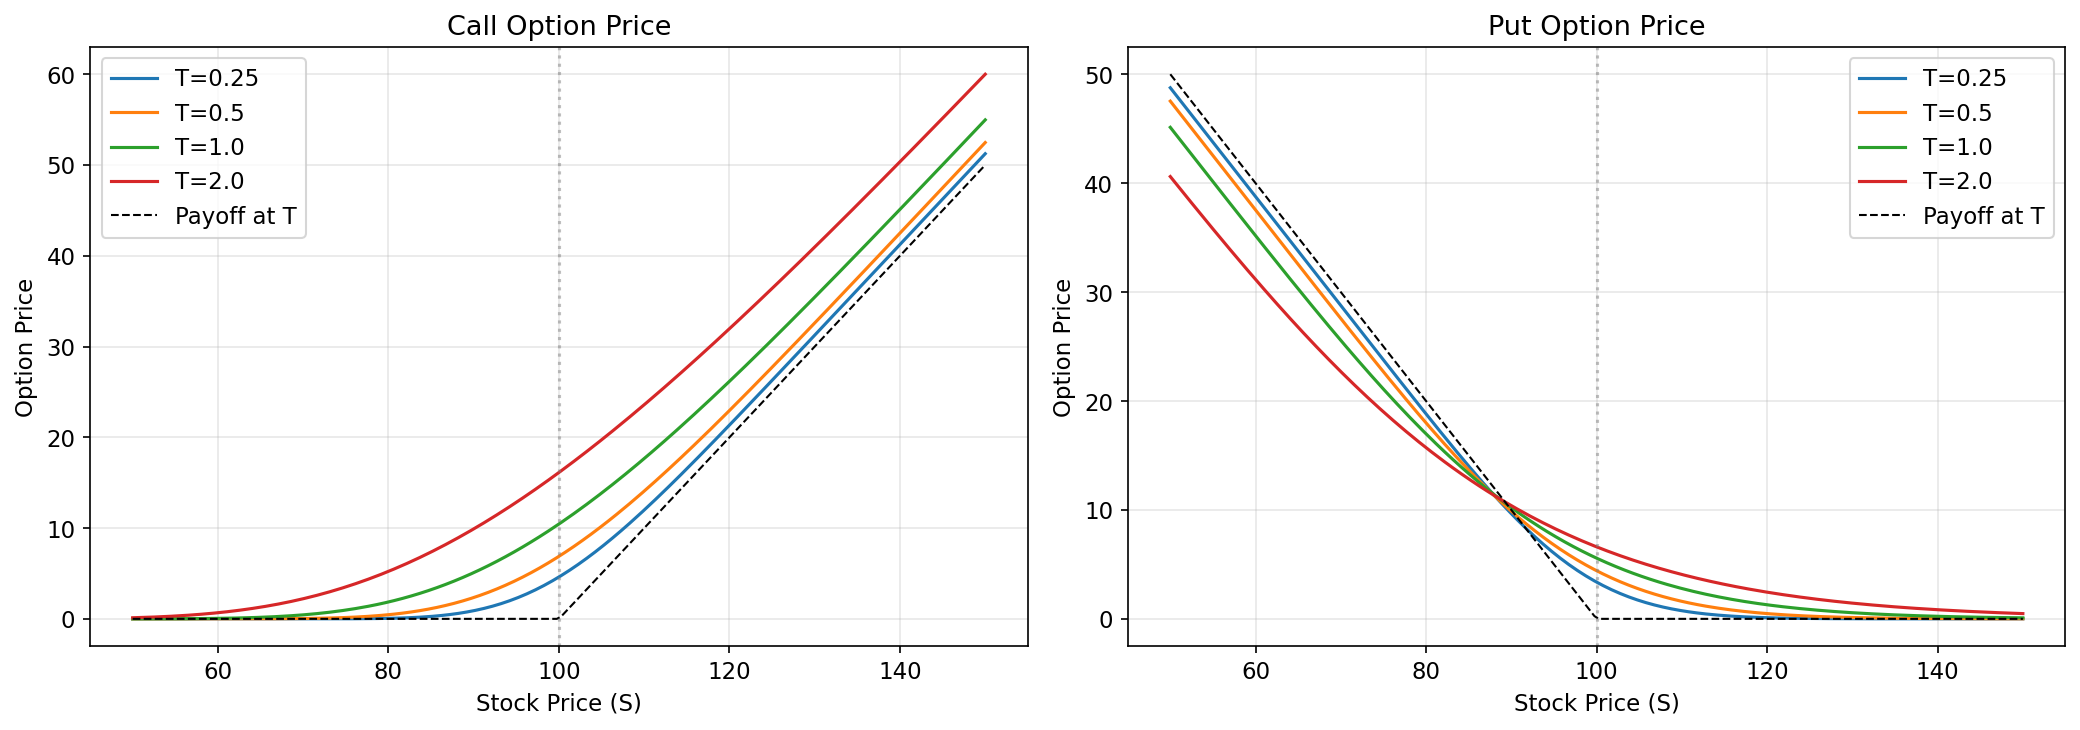

In [5]:
T_values = [0.25, 0.5, 1.0, 2.0]
S_range = np.linspace(50, 150, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for T in T_values:
    call_prices = bs_call(S_range, K, T, r, sigma)
    put_prices = bs_put(S_range, K, T, r, sigma)
    axes[0].plot(S_range, call_prices, linewidth=1.5, label=f'T={T}')
    axes[1].plot(S_range, put_prices, linewidth=1.5, label=f'T={T}')

axes[0].plot(S_range, np.maximum(S_range - K, 0), 'k--', linewidth=1, label='Payoff at T')
axes[1].plot(S_range, np.maximum(K - S_range, 0), 'k--', linewidth=1, label='Payoff at T')

for ax, title in zip(axes, ['Call Option Price', 'Put Option Price']):
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Stock Price (S)')
    ax.set_ylabel('Option Price')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axvline(x=K, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### 図3: コールオプション価格曲面

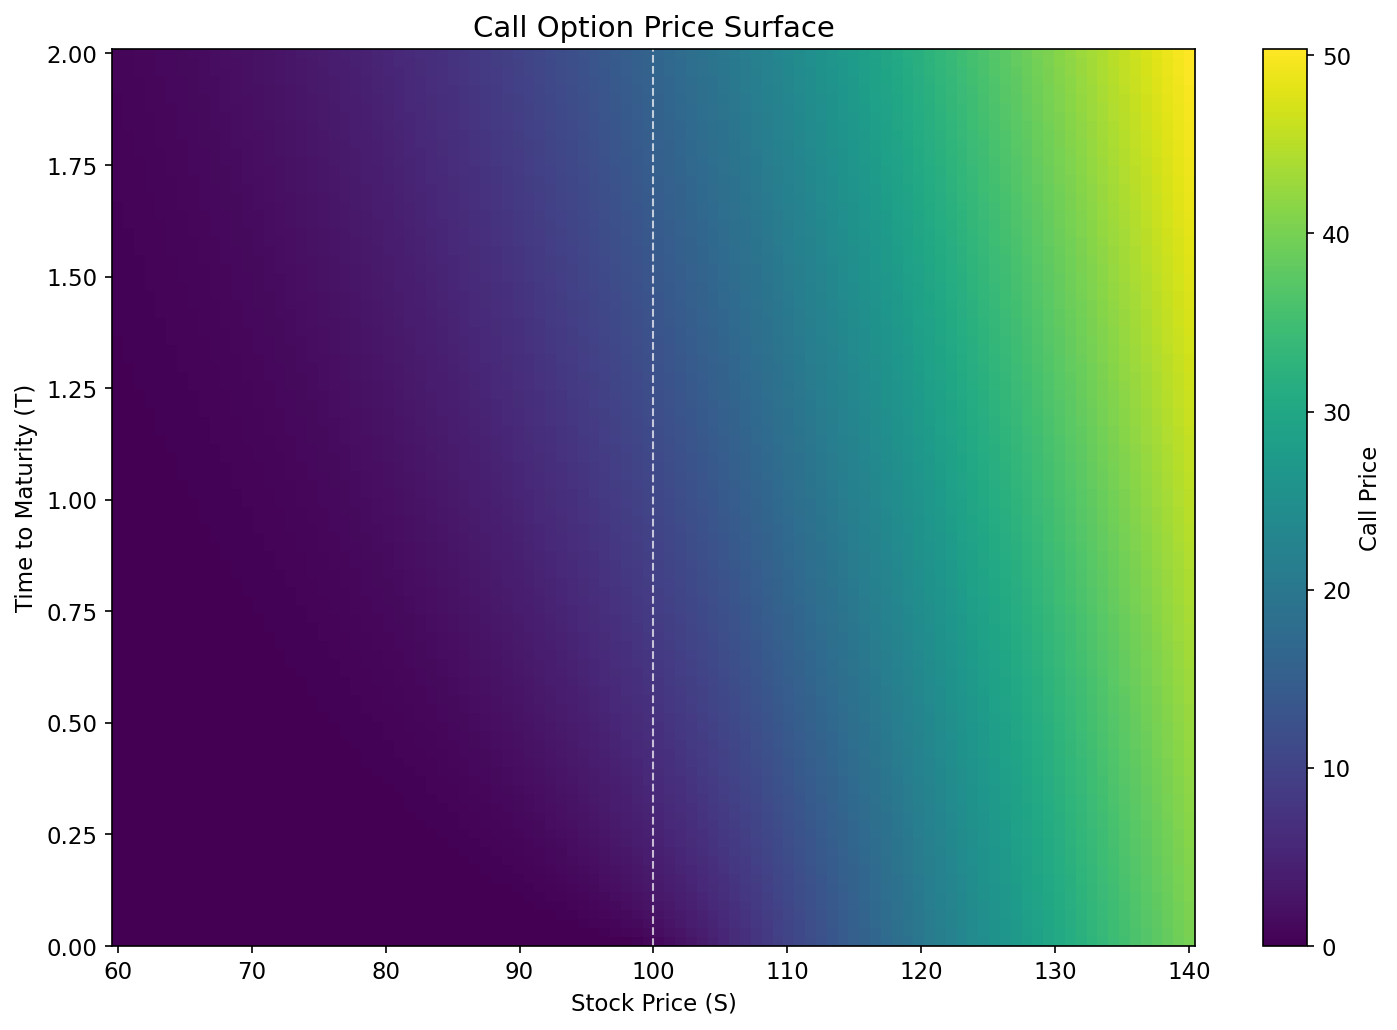

In [6]:
S_grid = np.linspace(60, 140, 100)
T_grid = np.linspace(0.01, 2.0, 100)
S_mesh, T_mesh = np.meshgrid(S_grid, T_grid)
C_mesh = bs_call(S_mesh, K, T_mesh, r, sigma)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.pcolormesh(S_mesh, T_mesh, C_mesh, cmap='viridis', shading='auto')
plt.colorbar(im, ax=ax, label='Call Price')
ax.set_title('Call Option Price Surface', fontsize=14)
ax.set_xlabel('Stock Price (S)')
ax.set_ylabel('Time to Maturity (T)')
ax.axvline(x=K, color='white', linestyle='--', linewidth=1, alpha=0.7)
plt.tight_layout()
plt.show()

## 4. グリークス（Greeks）

| Greek | 定義 | 意味 |
|:---:|:---:|:---:|
| Delta | $\partial V / \partial S$ | 原資産価格に対する感度 |
| Gamma | $\partial^2 V / \partial S^2$ | デルタの変化率 |
| Theta | $\partial V / \partial t$ | 時間減価 |
| Vega | $\partial V / \partial \sigma$ | ボラティリティに対する感度 |
| Rho | $\partial V / \partial r$ | 金利に対する感度 |

### グリークスの実装

In [7]:
def greeks(S, K, T, r, sigma):
    """全グリークスを計算"""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    delta_call = norm.cdf(d1)
    delta_put = norm.cdf(d1) - 1
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    theta_call = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
                  - r * K * np.exp(-r * T) * norm.cdf(d2))
    vega = S * norm.pdf(d1) * np.sqrt(T)
    rho_call = K * T * np.exp(-r * T) * norm.cdf(d2)

    return {
        'delta_call': delta_call, 'delta_put': delta_put,
        'gamma': gamma, 'theta_call': theta_call,
        'vega': vega, 'rho_call': rho_call
    }

# 数値例
g = greeks(S0, K, 1.0, r, sigma)
print(f"=== Greeks at S={S0}, K={K}, T=1.0, r={r}, sigma={sigma} ===")
for key, val in g.items():
    print(f"  {key}: {val:.6f}")

=== Greeks at S=100, K=100, T=1.0, r=0.05, sigma=0.2 ===
  delta_call: 0.636831
  delta_put: -0.363169
  gamma: 0.018762
  theta_call: -6.414028
  vega: 37.524035
  rho_call: 53.232482


### 図4: グリークスの可視化

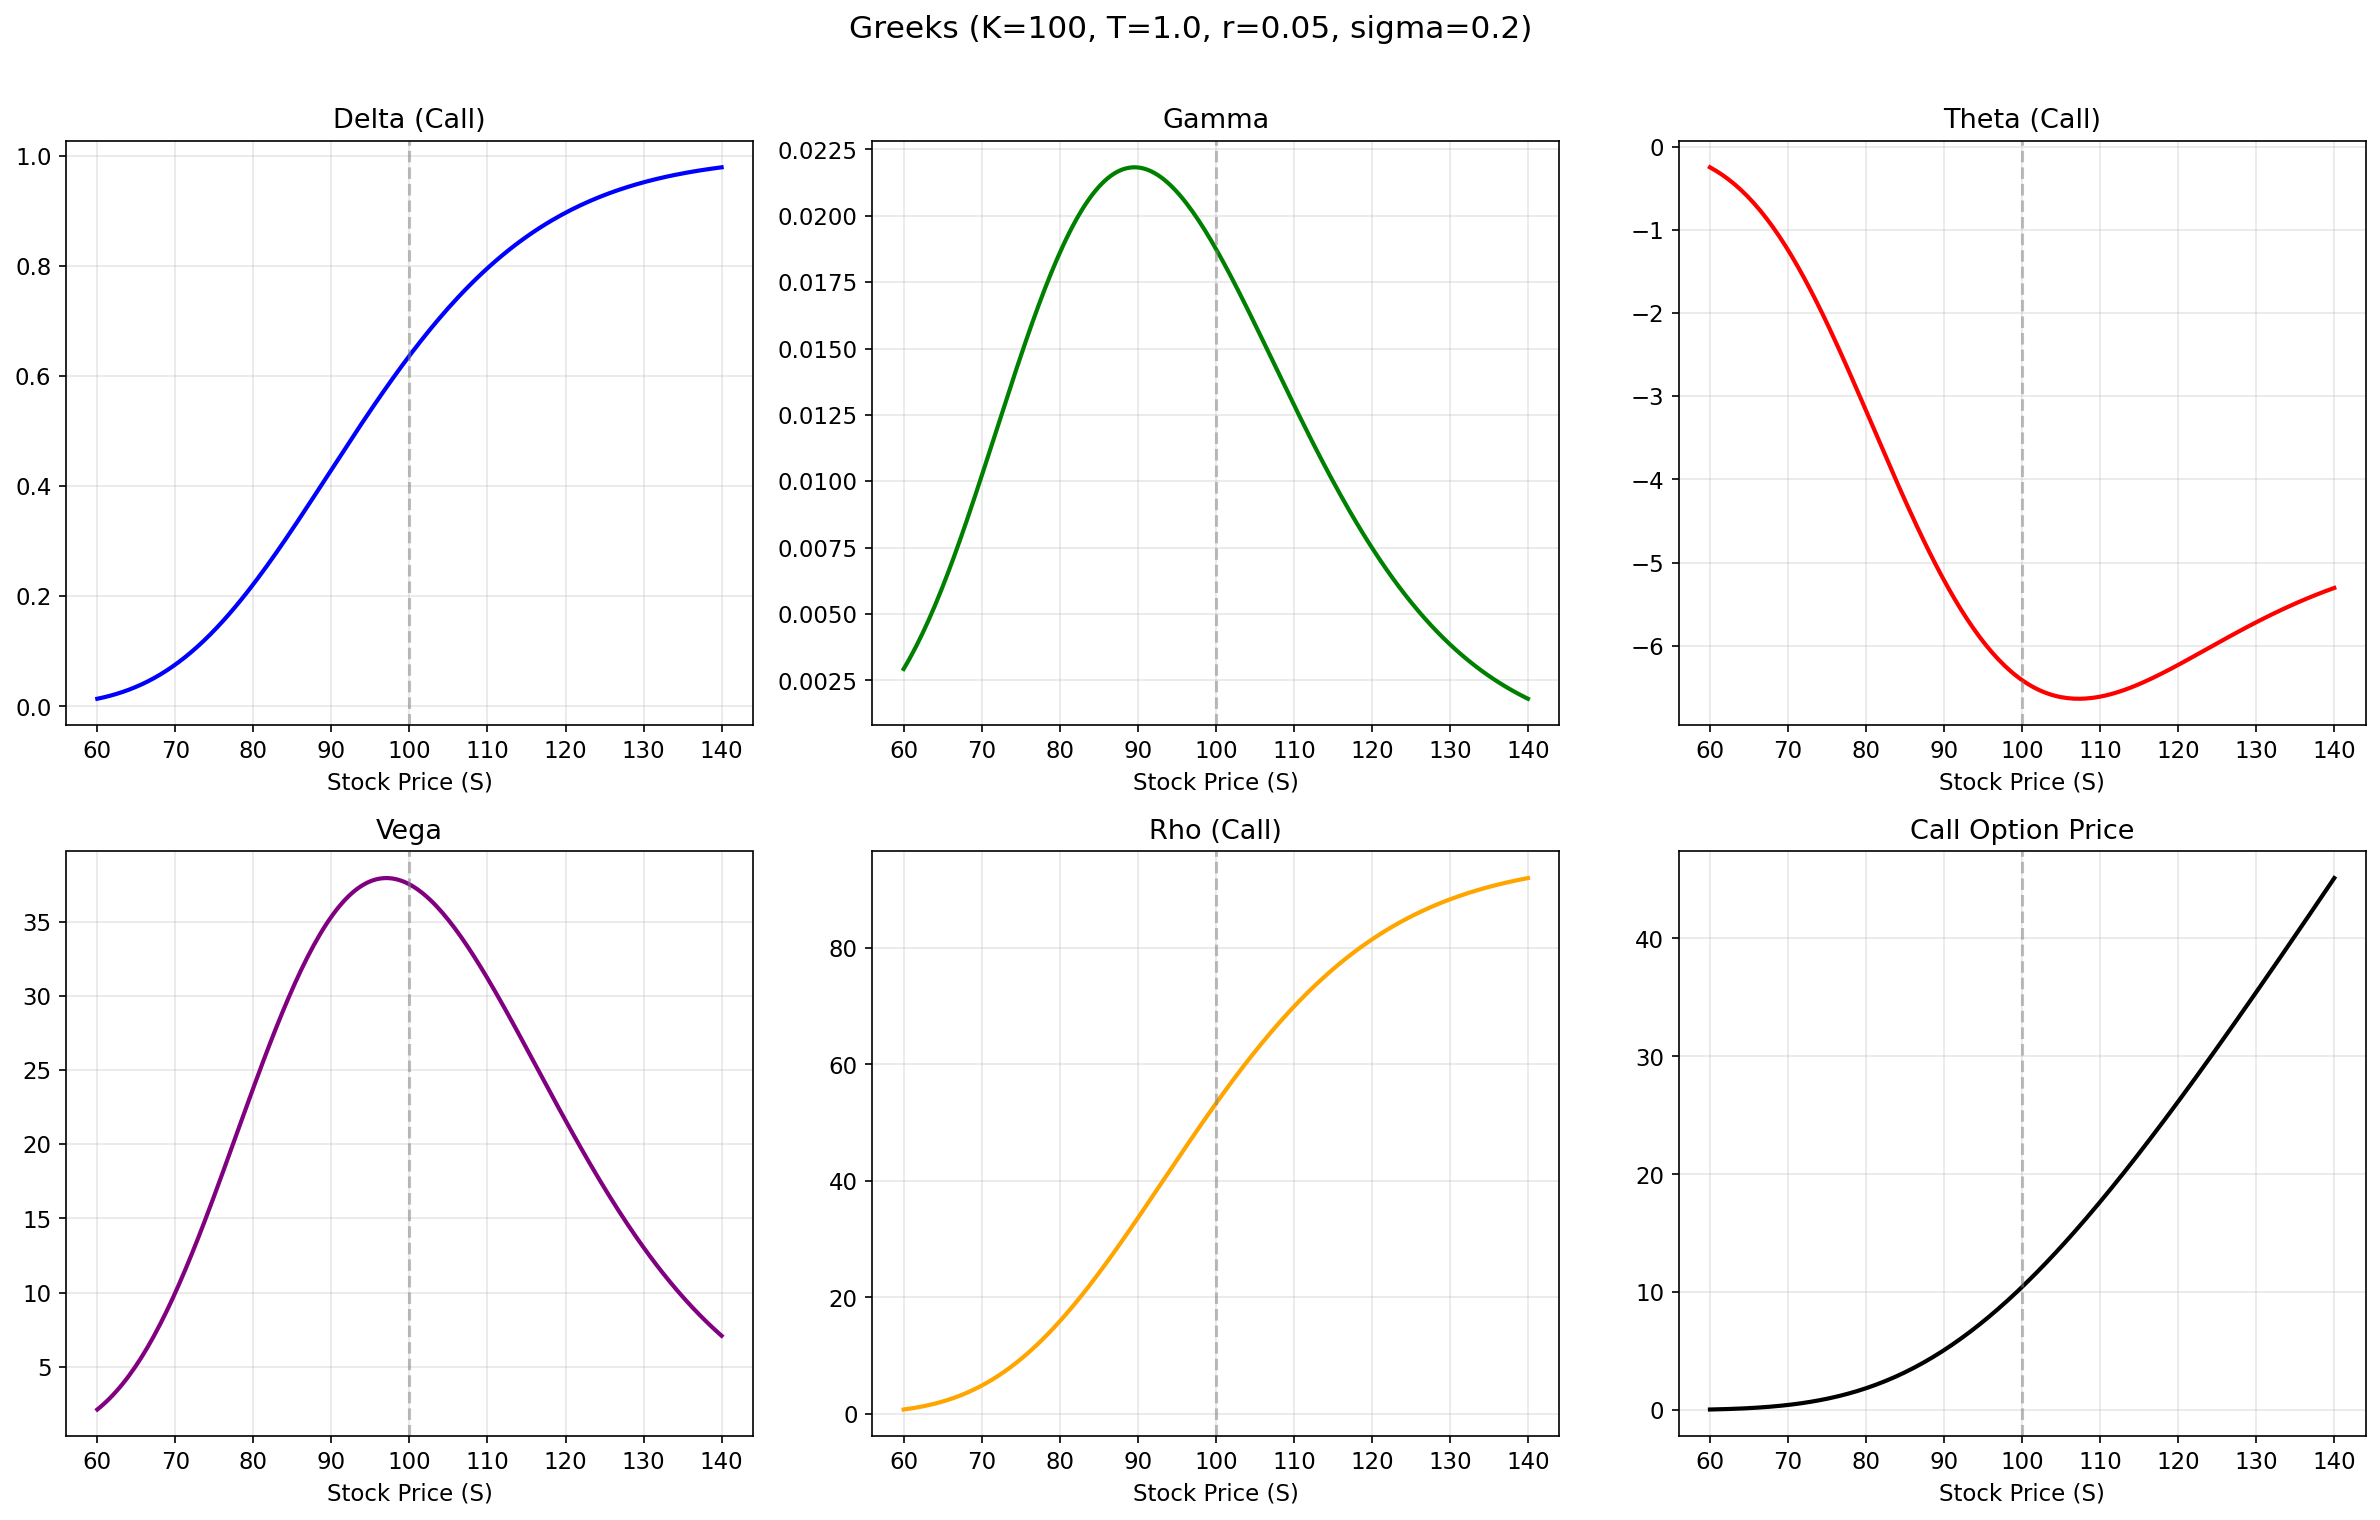

In [8]:
S_range = np.linspace(60, 140, 200)
T_val = 1.0

g = greeks(S_range, K, T_val, r, sigma)
call_price = bs_call(S_range, K, T_val, r, sigma)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

plots = [
    ('delta_call', 'Delta (Call)', 'blue'),
    ('gamma', 'Gamma', 'green'),
    ('theta_call', 'Theta (Call)', 'red'),
    ('vega', 'Vega', 'purple'),
    ('rho_call', 'Rho (Call)', 'orange'),
]

for ax, (key, title, color) in zip(axes.flatten()[:5], plots):
    ax.plot(S_range, g[key], linewidth=2, color=color)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Stock Price (S)')
    ax.axvline(x=K, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)

axes[1][2].plot(S_range, call_price, linewidth=2, color='black')
axes[1][2].set_title('Call Option Price', fontsize=13)
axes[1][2].set_xlabel('Stock Price (S)')
axes[1][2].axvline(x=K, color='gray', linestyle='--', alpha=0.5)
axes[1][2].grid(True, alpha=0.3)

plt.suptitle(f'Greeks (K={K}, T={T_val}, r={r}, sigma={sigma})', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 5. モンテカルロ法との比較

**リスク中立評価**: $C = e^{-rT} E^Q[\max(S_T - K, 0)]$

ドリフトを $\mu$ ではなく $r$ に置き換えてシミュレーション。

### モンテカルロによるオプション価格計算

In [9]:
def mc_option_price(S, K, T, r, sigma, n_simulations, option_type='call'):
    """モンテカルロ法によるオプション価格計算"""
    Z = np.random.standard_normal(n_simulations)
    S_T = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    if option_type == 'call':
        payoffs = np.maximum(S_T - K, 0)
    else:
        payoffs = np.maximum(K - S_T, 0)

    price = np.exp(-r * T) * np.mean(payoffs)
    std_error = np.exp(-r * T) * np.std(payoffs) / np.sqrt(n_simulations)
    return price, std_error

# BS解析解
bs_price = bs_call(S0, K, 1.0, r, sigma)
print(f"BS Analytical Price: {bs_price:.4f}")

# MC計算
np.random.seed(42)
mc_price, mc_se = mc_option_price(S0, K, 1.0, r, sigma, 1000000)
print(f"MC Price (1M paths): {mc_price:.4f} +/- {2*mc_se:.4f}")

BS Analytical Price: 10.4506
MC Price (1M paths): 10.4342 +/- 0.0294


### 図5: モンテカルロ vs BS解析解の収束

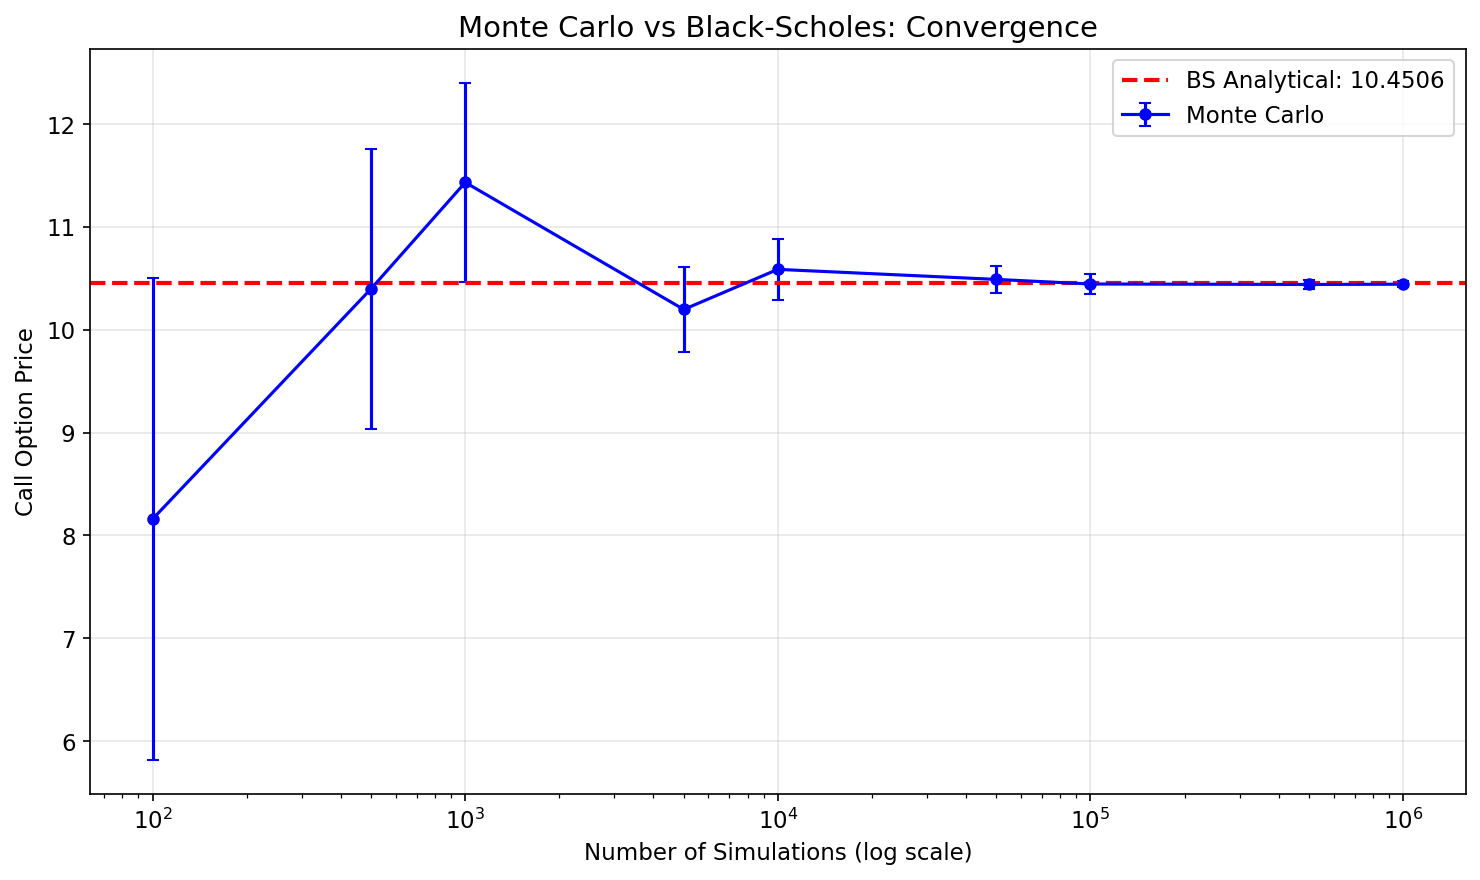

In [10]:
np.random.seed(42)
n_values = [100, 500, 1000, 5000, 10000, 50000, 100000, 500000, 1000000]
mc_prices = []
mc_errors = []

for n in n_values:
    price, se = mc_option_price(S0, K, 1.0, r, sigma, n)
    mc_prices.append(price)
    mc_errors.append(se)

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(n_values, mc_prices, yerr=[2*se for se in mc_errors],
            fmt='bo-', linewidth=1.5, markersize=5, capsize=3, label='Monte Carlo')
ax.axhline(y=bs_price, color='red', linestyle='--', linewidth=2,
           label=f'BS Analytical: {bs_price:.4f}')
ax.set_xscale('log')
ax.set_title('Monte Carlo vs Black-Scholes: Convergence', fontsize=14)
ax.set_xlabel('Number of Simulations (log scale)')
ax.set_ylabel('Call Option Price')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()